# 01 — Data Cleaning
**Projeto:** Give Me Some Credit — Classificação de Risco de Crédito  
**Notebook:** `01_data_cleaning.ipynb`  
**Autor:** Eduardo EMF  
**Repositório:** [credit-risk-classifier](https://github.com/eduardoemf/credit-risk-classifier)

---

## 🎯 Objetivo

Este notebook realiza o pipeline completo de limpeza de dados do dataset da competição [Give Me Some Credit](https://www.kaggle.com/competitions/GiveMeSomeCredit/overview), cobrindo:

1. Carregamento e inspeção inicial
2. Padronização de nomes e reordenação de colunas
3. Tratamento de valores ausentes (`monthly_income`, `num_dependents`)
4. Validação e correção de valores impossíveis ou extremos (caps por percentil)
5. Exportação do dataset limpo para uso nas próximas etapas

O output deste notebook é o arquivo `cs-training_cleaned.parquet`, consumido por `02_analise_exploratoria.ipynb`.

---

## 📘 Dicionário de Dados — Dataset Original

| Coluna Original | Coluna Padronizada | Tipo | Descrição |
|---|---|---|---|
| `SeriousDlqin2yrs` | `target_default_2y` | Binária | Inadimplência séria nos próximos 2 anos (1 = sim, 0 = não) |
| `RevolvingUtilizationOfUnsecuredLines` | `revolving_utilization` | Contínua | % de uso do crédito rotativo não garantido (0–1) |
| `age` | `age` | Contínua | Idade do cliente em anos |
| `DebtRatio` | `debt_ratio` | Contínua | Relação entre despesas mensais e renda mensal |
| `MonthlyIncome` | `monthly_income` | Contínua | Renda mensal do cliente |
| `NumberOfOpenCreditLinesAndLoans` | `num_credit_lines` | Discreta | Total de linhas de crédito e empréstimos em aberto |
| `NumberOfTime30-59DaysPastDueNotWorse` | `late_30_59_days` | Discreta | Nº de atrasos entre 30–59 dias (últimos 2 anos) |
| `NumberOfTime60-89DaysPastDueNotWorse` | `late_60_89_days` | Discreta | Nº de atrasos entre 60–89 dias (últimos 2 anos) |
| `NumberOfTimes90DaysLate` | `late_90_plus_days` | Discreta | Nº de atrasos ≥ 90 dias (últimos 2 anos) |
| `NumberRealEstateLoansOrLines` | `num_real_estate_loans` | Discreta | Nº de financiamentos imobiliários ativos |
| `NumberOfDependents` | `num_dependents` | Discreta | Nº de dependentes (excluindo cônjuge) |

---

## ⚙️ Configuração do Ambiente

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import normaltest

# ── Opções de exibição ──────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# ── Tema visual padronizado ─────────────────────────────────────────
PALETTE_MAIN = 'steelblue'

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize'   : (10, 4),
    'figure.dpi'       : 110,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

---

## 1. Carregamento e Inspeção Inicial

In [2]:
# Leitura dos dados brutos
df = pd.read_csv('../data/raw/cs-training.csv')

In [3]:
# Dimensões do dataset bruto
df.shape

(150000, 12)

In [4]:
# Primeiras linhas — verificação visual rápida
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
1,2,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
2,3,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
3,4,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
4,5,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00


> A coluna `Unnamed: 0` é um índice numérico gerado na exportação original do CSV — não carrega informação de negócio e será removida.

In [5]:
# Remoção da coluna de índice sem valor analítico
df.drop(columns='Unnamed: 0', inplace=True)

---

## 2. Padronização de Nomes e Ordenação de Colunas

Nomes no padrão `snake_case` tornam o código mais legível, reduzem erros de digitação e facilitam o acesso por atributo (ex: `df.monthly_income`).  
A reordenação coloca o target em primeiro e agrupa as variáveis por natureza (financeiras contínuas → volume de crédito → histórico de atraso → perfil pessoal).

In [6]:
column_mapping = {
    'SeriousDlqin2yrs'                      : 'target_default_2y',
    'age'                                   : 'age',
    'RevolvingUtilizationOfUnsecuredLines'  : 'revolving_utilization',
    'NumberOfTime30-59DaysPastDueNotWorse'  : 'late_30_59_days',
    'NumberOfTime60-89DaysPastDueNotWorse'  : 'late_60_89_days',
    'NumberOfTimes90DaysLate'               : 'late_90_plus_days',
    'MonthlyIncome'                         : 'monthly_income',
    'DebtRatio'                             : 'debt_ratio',
    'NumberOfOpenCreditLinesAndLoans'       : 'num_credit_lines',
    'NumberRealEstateLoansOrLines'          : 'num_real_estate_loans',
    'NumberOfDependents'                    : 'num_dependents',
}

df_renamed = df.rename(columns=column_mapping)
del df  # Libera memória do dataframe original

In [7]:
# Reordenação lógica das colunas
col_order = [
    'target_default_2y',
    'revolving_utilization',
    'age',
    'debt_ratio',
    'monthly_income',
    'num_credit_lines',
    'late_30_59_days',
    'late_60_89_days',
    'late_90_plus_days',
    'num_real_estate_loans',
    'num_dependents',
]

df_renamed = df_renamed[col_order]
df_renamed.head()

,target_default_2y,revolving_utilization,age,debt_ratio,monthly_income,num_credit_lines,late_30_59_days,late_60_89_days,late_90_plus_days,num_real_estate_loans,num_dependents
0,1,0.77,45,0.80,9120.00,13,2,0,0,6,2.00
1,0,0.96,40,0.12,2600.00,4,0,0,0,0,1.00
2,0,0.66,38,0.09,3042.00,2,1,0,1,0,0.00
3,0,0.23,30,0.04,3300.00,5,0,0,0,0,0.00
4,0,0.91,49,0.02,63588.00,7,1,0,0,1,0.00


---

## 3. Tipagem e Valores Ausentes

In [8]:
df_renamed.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   target_default_2y      150000 non-null  int64  
 1   revolving_utilization  150000 non-null  float64
 2   age                    150000 non-null  int64  
 3   debt_ratio             150000 non-null  float64
 4   monthly_income         120269 non-null  float64
 5   num_credit_lines       150000 non-null  int64  
 6   late_30_59_days        150000 non-null  int64  
 7   late_60_89_days        150000 non-null  int64  
 8   late_90_plus_days      150000 non-null  int64  
 9   num_real_estate_loans  150000 non-null  int64  
 10  num_dependents         146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


> O dataset conta com **150.000 registros** e 11 variáveis após a remoção do índice.  
> Duas colunas apresentam valores ausentes que requerem tratamento:
> - `monthly_income` — variável contínua de renda
> - `num_dependents` — variável discreta de perfil familiar

In [9]:
# Percentual de valores ausentes por coluna
missing = (df_renamed.isna().mean() * 100).sort_values(ascending=False)
print(missing[missing > 0])

monthly_income   19.82
num_dependents    2.62
dtype: float64


### 3.1 Imputação: `monthly_income`

Variáveis de renda tipicamente apresentam assimetria positiva e outliers nas faixas altas — o que invalida o uso da média como representante central.  
A estratégia correta é confirmar a distribuição com um teste de normalidade e, se não-normal, imputar pela **mediana**.

In [10]:
# Comparação entre média e mediana
mean_income   = df_renamed['monthly_income'].mean()
median_income = df_renamed['monthly_income'].median()

print(f'Média:   {mean_income:,.2f}')
print(f'Mediana: {median_income:,.2f}')
print(f'Diferença: {((mean_income - median_income) / median_income * 100):.1f}% — indica presença de outliers superiores')

Média:   6,670.22
Mediana: 5,400.00
Diferença: 23.5% — indica presença de outliers superiores


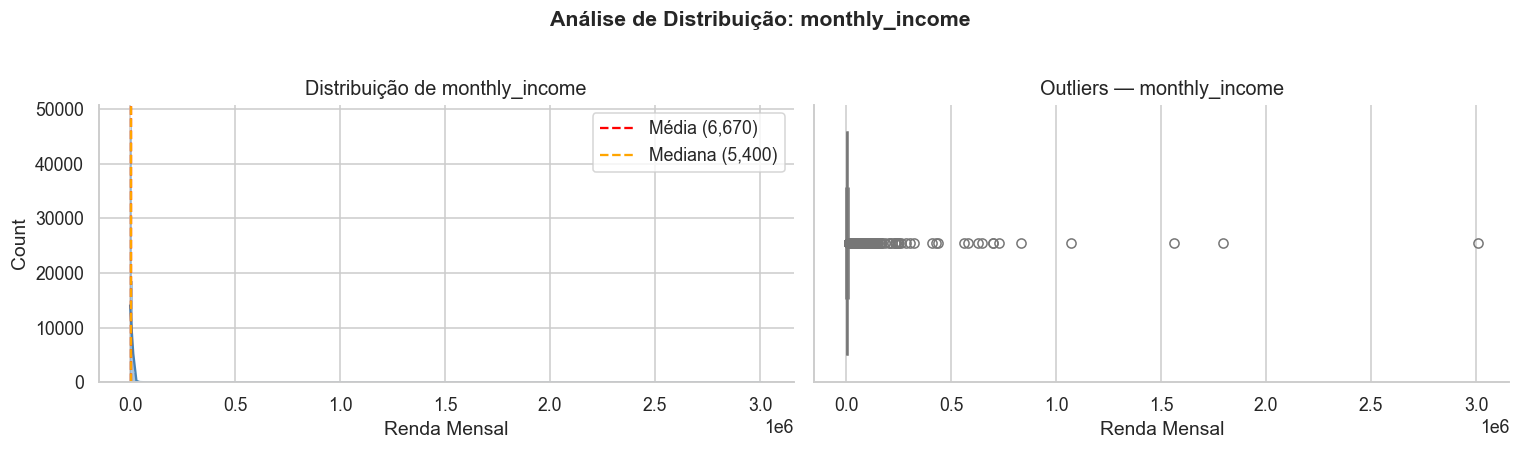

In [11]:
# Distribuição visual da renda
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_renamed['monthly_income'].dropna().pipe(
    lambda s: sns.histplot(s, kde=True, color=PALETTE_MAIN, ax=axes[0])
)
axes[0].set_title('Distribuição de monthly_income', fontsize=13)
axes[0].set_xlabel('Renda Mensal')
axes[0].axvline(mean_income,   color='red',    linestyle='--', label=f'Média ({mean_income:,.0f})')
axes[0].axvline(median_income, color='orange', linestyle='--', label=f'Mediana ({median_income:,.0f})')
axes[0].legend()

sns.boxplot(x=df_renamed['monthly_income'].dropna(), color='lightsteelblue', ax=axes[1])
axes[1].set_title('Outliers — monthly_income', fontsize=13)
axes[1].set_xlabel('Renda Mensal')

plt.suptitle('Análise de Distribuição: monthly_income', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Teste de normalidade D'Agostino-Pearson
stat, p = normaltest(df_renamed['monthly_income'].dropna())

print(f'Estatística: {stat:.4f}')
print(f'P-valor:     {p:.2e}')
print()
if p < 0.05:
    print('✅ Rejeitamos H0 — distribuição NÃO é normal. Imputação pela mediana é a abordagem correta.')

Estatística: 497862.3610
P-valor:     0.00e+00

✅ Rejeitamos H0 — distribuição NÃO é normal. Imputação pela mediana é a abordagem correta.


In [13]:
# Imputação pela mediana
df_renamed['monthly_income'] = df_renamed['monthly_income'].fillna(median_income)

print(f'Mediana utilizada para imputação: {median_income:,.2f}')
print(f'Valores ausentes remanescentes: {df_renamed["monthly_income"].isna().sum()}')

Mediana utilizada para imputação: 5,400.00
Valores ausentes remanescentes: 0


### 3.2 Imputação: `num_dependents`

Variável discreta com forte concentração em poucos valores inteiros. Para esse perfil, a **moda** (valor mais frequente) é a estratégia de imputação mais adequada — evita introdução de valores fracionários artificiais e preserva a distribuição original.

In [14]:
# Distribuição dos valores presentes
print('Distribuição de num_dependents:')
print(df_renamed['num_dependents'].value_counts(normalize=True).mul(100).round(2).to_string())
print(f'\nValores ausentes: {df_renamed["num_dependents"].isna().sum():,}')

Distribuição de num_dependents:
num_dependents
0.00    59.49
1.00    18.02
2.00    13.36
3.00     6.49
4.00     1.96
5.00     0.51
6.00     0.11
7.00     0.03
8.00     0.02
10.00    0.00
9.00     0.00
20.00    0.00
13.00    0.00

Valores ausentes: 3,924


In [15]:
# Estatísticas descritivas
df_renamed['num_dependents'].describe()

count   146076.00
mean         0.76
std          1.12
min          0.00
25%          0.00
50%          0.00
75%          1.00
max         20.00
Name: num_dependents, dtype: float64

In [16]:
# Imputação pela moda
moda_dependents = df_renamed['num_dependents'].mode()[0]
df_renamed['num_dependents'] = df_renamed['num_dependents'].fillna(moda_dependents)

print(f'Moda utilizada para imputação: {moda_dependents}')
print(f'Valores ausentes remanescentes: {df_renamed["num_dependents"].isna().sum()}')

Moda utilizada para imputação: 0.0
Valores ausentes remanescentes: 0


### 3.3 Verificação Pós-Imputação

In [17]:
df_renamed.info()
print()
missing_pos = (df_renamed.isna().mean() * 100).sort_values(ascending=False)
print('Valores ausentes após imputação:')
print(missing_pos[missing_pos > 0] if missing_pos.any() else '✅ Nenhum valor ausente remanescente.')

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   target_default_2y      150000 non-null  int64  
 1   revolving_utilization  150000 non-null  float64
 2   age                    150000 non-null  int64  
 3   debt_ratio             150000 non-null  float64
 4   monthly_income         150000 non-null  float64
 5   num_credit_lines       150000 non-null  int64  
 6   late_30_59_days        150000 non-null  int64  
 7   late_60_89_days        150000 non-null  int64  
 8   late_90_plus_days      150000 non-null  int64  
 9   num_real_estate_loans  150000 non-null  int64  
 10  num_dependents         150000 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB

Valores ausentes após imputação:
✅ Nenhum valor ausente remanescente.


---

## 4. Validação e Tratamento de Valores Extremos

Cada variável possui um domínio lógico de valores válidos. Nesta seção identificamos violações desse domínio e aplicamos **caps por percentil** para preservar a estrutura da variável sem excluir registros.

### 4.0 Verificação de Valores Negativos

In [18]:
# Nenhuma variável numérica deveria ter valor negativo neste contexto
negativos = df_renamed[(df_renamed < 0).any(axis=1)]
print(f'Registros com valor negativo: {len(negativos)}')
if len(negativos) == 0:
    print('✅ Nenhum valor negativo encontrado — dataset íntegro nesta dimensão.')

Registros com valor negativo: 0
✅ Nenhum valor negativo encontrado — dataset íntegro nesta dimensão.


In [19]:
# Visão geral das estatísticas — base para identificar candidatos a tratamento
df_renamed.describe().T

,count,mean,std,min,25%,50%,75%,max
target_default_2y,150000.00,0.07,0.25,0.00,0.00,0.00,0.00,1.00
revolving_utilization,150000.00,6.05,249.76,0.00,0.03,0.15,0.56,50708.00
age,150000.00,52.30,14.77,0.00,41.00,52.00,63.00,109.00
debt_ratio,150000.00,353.01,2037.82,0.00,0.18,0.37,0.87,329664.00
monthly_income,150000.00,6418.45,12890.40,0.00,3903.00,5400.00,7400.00,3008750.00
num_credit_lines,150000.00,8.45,5.15,0.00,5.00,8.00,11.00,58.00
late_30_59_days,150000.00,0.42,4.19,0.00,0.00,0.00,0.00,98.00
late_60_89_days,150000.00,0.24,4.16,0.00,0.00,0.00,0.00,98.00
late_90_plus_days,150000.00,0.27,4.17,0.00,0.00,0.00,0.00,98.00
num_real_estate_loans,150000.00,1.02,1.13,0.00,0.00,1.00,2.00,54.00


### 4.1 Função Auxiliar de Análise e Cap
Para garantir consistência no tratamento de cada variável, utilizamos uma função padronizada que:
- Exibe distribuição e boxplot antes e após o cap;
- Aplica o cap no percentil especificado;
- Reporta os limites utilizados.

In [20]:
def analyze_and_cap(df, column, percentile=0.995, lower=0.0):
    """
    Analisa e aplica cap por percentil em uma variável numérica.

    Exibe boxplot antes/depois do tratamento e reporta os limites aplicados.

    Args:
        df (pd.DataFrame): DataFrame a ser modificado in-place.
        column (str): Nome da coluna a tratar.
        percentile (float): Percentil superior para o cap (padrão: 0.995).
        lower (float): Limite inferior (padrão: 0.0).

    Returns:
        float: Valor do cap superior aplicado.
    """
    cap = df[column].quantile(percentile)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.boxplot(x=df[column], color='lightsteelblue', ax=axes[0])
    axes[0].set_title(f'Antes do cap — {column}', fontsize=12)
    axes[0].set_xlabel(column)
    axes[0].axvline(cap, color='red', linestyle='--', label=f'Cap p{percentile*100:.1f} = {cap:.2f}')
    axes[0].legend()

    df[column] = df[column].clip(lower, cap)

    sns.boxplot(x=df[column], color=PALETTE_MAIN, ax=axes[1])
    axes[1].set_title(f'Após o cap — {column}', fontsize=12)
    axes[1].set_xlabel(column)

    plt.suptitle(f'Tratamento de Outliers: {column}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    n_afetados = (df[column] == cap).sum()
    print(f'📌 {column}: cap aplicado em p{percentile*100:.1f} = {cap:.4f}  |  registros afetados: {n_afetados:,}')

    return cap

### 4.2 `revolving_utilization`

Esta variável representa o percentual de uso do limite de crédito rotativo.  
**Domínio teórico:** 0,0 (nenhum uso) a 1,0 (limite totalmente utilizado).  
Valores acima de 1,0 são tecnicamente possíveis em situação de estouro de limite, mas valores na casa de dezenas de milhares são erros de registro e distorcem completamente qualquer análise.  
**Decisão:** cap fixo em 1,0 — representa 100% do limite, o valor máximo semanticamente coerente.

In [21]:
# Volumes acima de 1.0 — diagnóstico
acima_1 = df_renamed.query('revolving_utilization > 1.0')['revolving_utilization']
print(f'Registros com utilização > 1.0: {len(acima_1):,}')
print(f'Valor máximo bruto: {acima_1.max():,.2f}')
print(f'Percentil 99.9: {df_renamed["revolving_utilization"].quantile(0.999):,.4f}')

Registros com utilização > 1.0: 3,321
Valor máximo bruto: 50,708.00
Percentil 99.9: 1,571.0060


Máximo antes: 50,708.00  →  Máximo após: 1.00
Registros afetados: 3,338


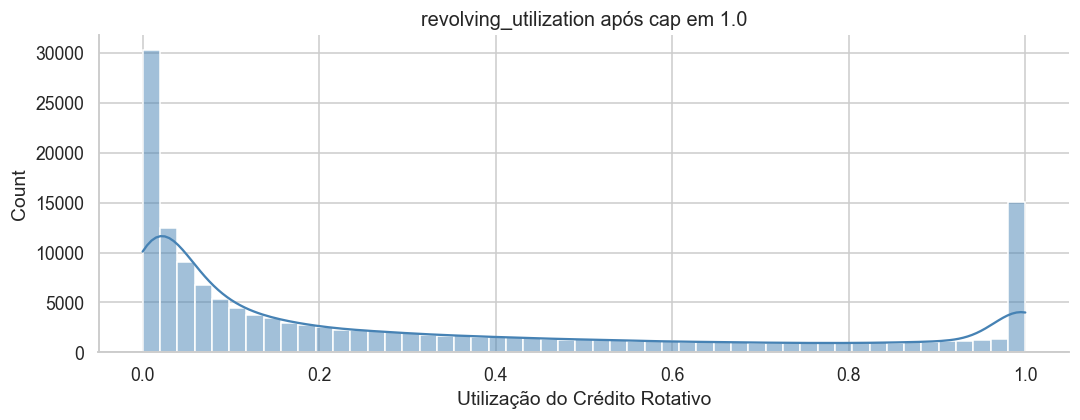

In [22]:
# Cap fixo em 1.0 (limite semântico do campo)
before_max = df_renamed['revolving_utilization'].max()
df_renamed['revolving_utilization'] = df_renamed['revolving_utilization'].clip(0.0, 1.0)
after_max  = df_renamed['revolving_utilization'].max()

print(f'Máximo antes: {before_max:,.2f}  →  Máximo após: {after_max:.2f}')
print(f'Registros afetados: {(df_renamed["revolving_utilization"] == 1.0).sum():,}')

# Visualização pós-cap
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df_renamed['revolving_utilization'], kde=True, color=PALETTE_MAIN, ax=ax)
ax.set_title('revolving_utilization após cap em 1.0', fontsize=13)
ax.set_xlabel('Utilização do Crédito Rotativo')
plt.tight_layout()
plt.show()

> **Decisão:** Cap fixo em **1,0** — limite semântico do campo. Valores acima de 1,0 em crédito rotativo são inconsistências de dados, não situações financeiras reais.

### 4.3 `age`

A idade mínima legal para contração de dívidas fica em torno de 18–21 anos dependendo da jurisdição.  
Registros com idade 0 são claramente erros de entrada e devem ser removidos — não é um outlier estatístico, é um valor impossível no contexto do negócio.

Idades < 21 anos:
age
0    1
Name: count, dtype: int64


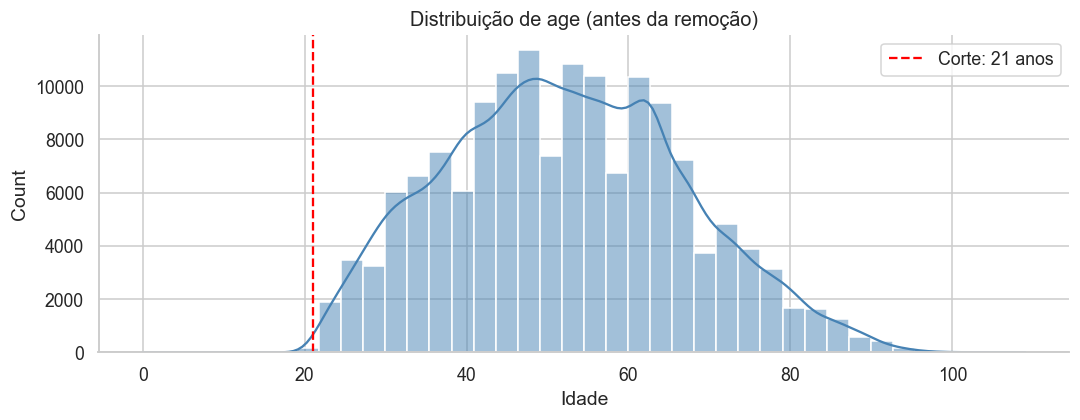

In [23]:
# Diagnóstico de idades inválidas
print('Idades < 21 anos:')
print(df_renamed.query('age < 21')['age'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df_renamed['age'], kde=True, color=PALETTE_MAIN, bins=40, ax=ax)
ax.set_title('Distribuição de age (antes da remoção)', fontsize=13)
ax.set_xlabel('Idade')
ax.axvline(21, color='red', linestyle='--', label='Corte: 21 anos')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# Remoção de registros com idade < 21 anos (valores impossíveis para o contexto)
n_antes = len(df_renamed)
df_renamed = df_renamed.query('age >= 21').copy()
n_depois = len(df_renamed)

print(f'Registros removidos: {n_antes - n_depois}  ({(n_antes - n_depois)/n_antes*100:.4f}% do total)')
print(f'Registros restantes: {n_depois:,}')

Registros removidos: 1  (0.0007% do total)
Registros restantes: 149,999


> **Decisão:** Remoção dos registros com `age < 21` anos — representam erros de entrada (apenas 1 registro com idade 0) e não representam potenciais tomadores de crédito válidos.

### 4.4 `debt_ratio`

Diferente de `revolving_utilization`, o debt ratio **não possui limite natural em 1,0** — valores acima de 100% representam superendividamento real e carregam informação de negócio relevante.  
Aplicamos cap no **percentil 99** para remover apenas os extremos estatisticamente improváveis, preservando o sinal de superendividamento.

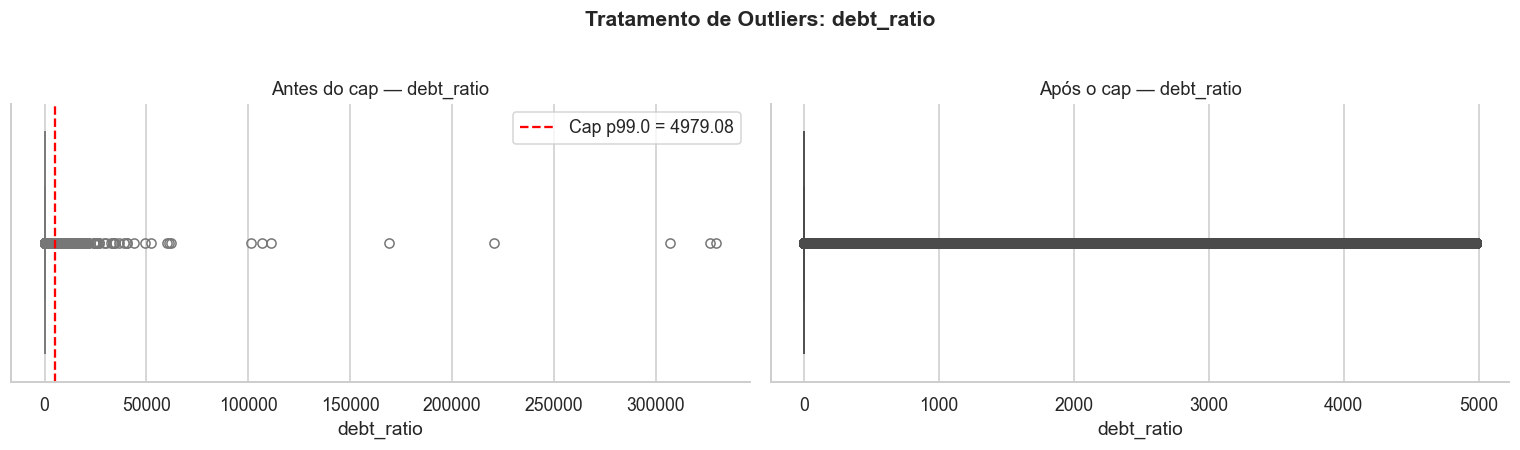

📌 debt_ratio: cap aplicado em p99.0 = 4979.0800  |  registros afetados: 1,500


In [25]:
cap_debt = analyze_and_cap(df_renamed, 'debt_ratio', percentile=0.99)

> **Decisão:** Cap no **percentil 99** — preserva a informação de superendividamento (valores >1,0 válidos) e remove apenas os extremos inconsistentes.

### 4.5 `monthly_income`

Rendas muito elevadas são plausíveis na realidade, mas os valores mais extremos desta base podem refletir erros de registro ou clientes não representativos da população de interesse.  
Cap no **percentil 99** preserva a variabilidade natural da renda sem distorcer a distribuição.

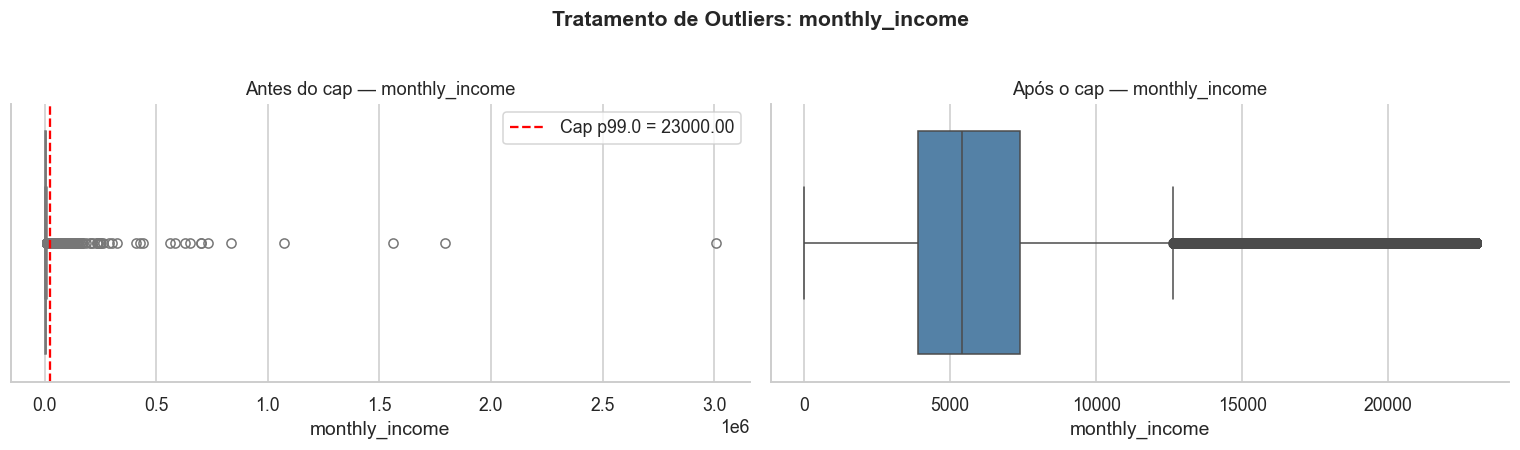

📌 monthly_income: cap aplicado em p99.0 = 23000.0000  |  registros afetados: 1,525


In [26]:
cap_income = analyze_and_cap(df_renamed, 'monthly_income', percentile=0.99)

> **Decisão:** Cap no **percentil 99** — prática padrão em modelagem de risco de crédito para variáveis de renda com outliers extremos.

### 4.6 `num_credit_lines`

Número total de linhas de crédito abertas. Valores muito altos (dezenas) não refletem o comportamento típico de consumidores e podem indicar erros de agregação de dados.

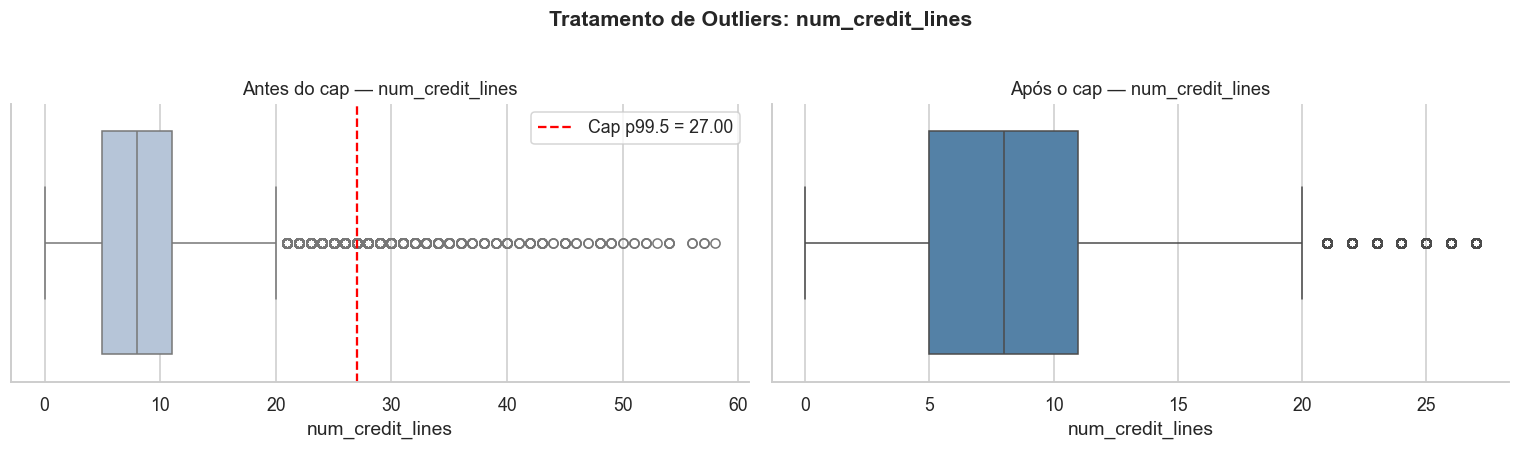

📌 num_credit_lines: cap aplicado em p99.5 = 27.0000  |  registros afetados: 900


In [27]:
cap_cl = analyze_and_cap(df_renamed, 'num_credit_lines', percentile=0.995)

> **Decisão:** Cap no **percentil 99,5** — remove os extremos sem afetar a distribuição central da variável.

### 4.7 Variáveis de Histórico de Atraso

As três variáveis de atraso (`late_30_59_days`, `late_60_89_days`, `late_90_plus_days`) compartilham a mesma natureza: **contagem de ocorrências** de inadimplência em diferentes faixas de severidade.  
Aplicamos o mesmo critério a todas: cap no **percentil 99,5**, removendo apenas contagens impossíveis de ocorrer na janela temporal de 2 anos.

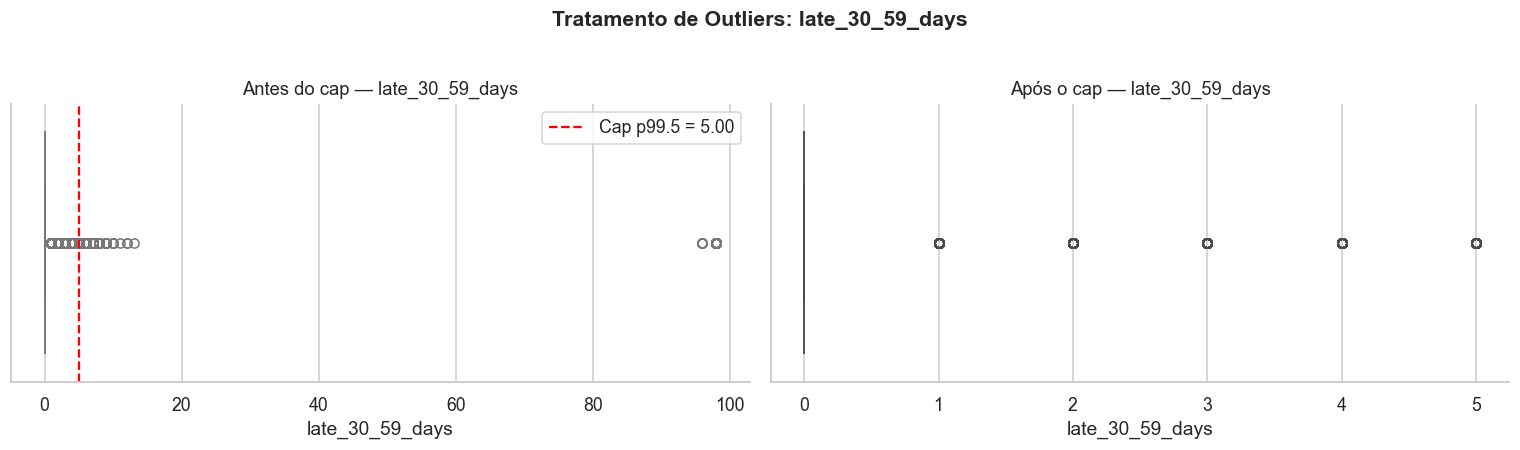

📌 late_30_59_days: cap aplicado em p99.5 = 5.0000  |  registros afetados: 850


In [28]:
# late_30_59_days
cap_l30 = analyze_and_cap(df_renamed, 'late_30_59_days', percentile=0.995)

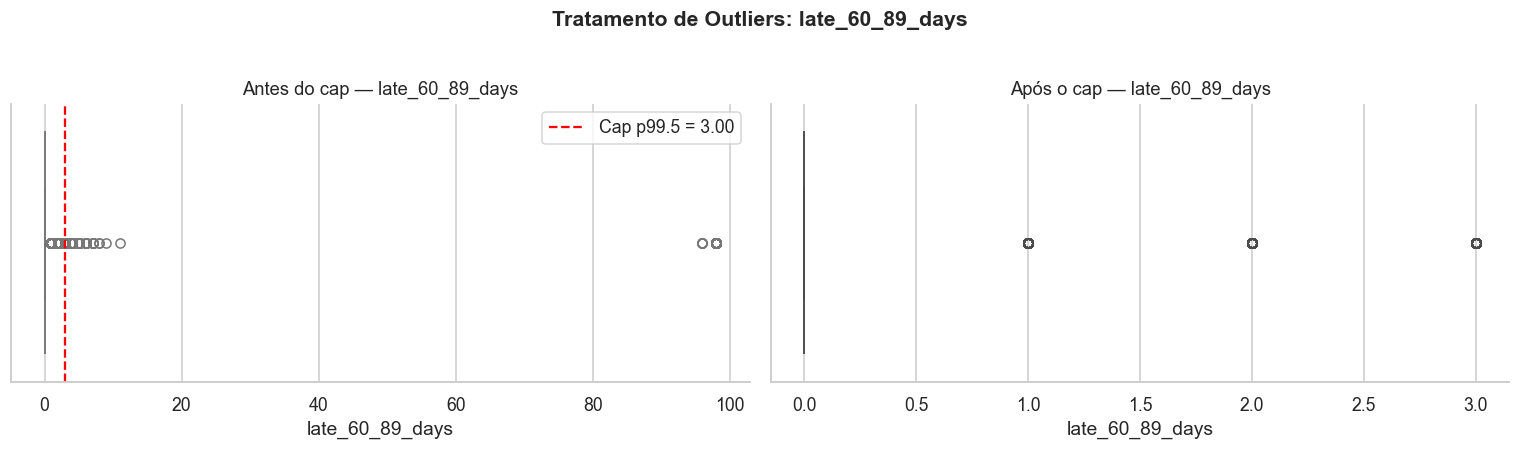

📌 late_60_89_days: cap aplicado em p99.5 = 3.0000  |  registros afetados: 755


In [29]:
# late_60_89_days
cap_l60 = analyze_and_cap(df_renamed, 'late_60_89_days', percentile=0.995)

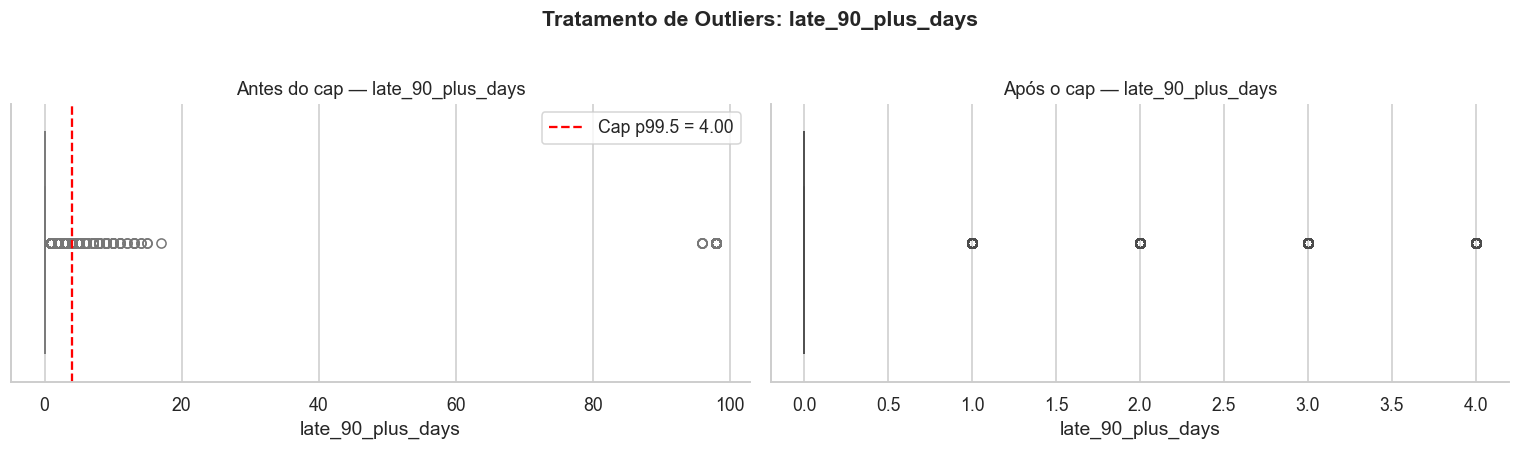

📌 late_90_plus_days: cap aplicado em p99.5 = 4.0000  |  registros afetados: 873


In [30]:
# late_90_plus_days
cap_l90 = analyze_and_cap(df_renamed, 'late_90_plus_days', percentile=0.995)

> **Decisão uniforme para as três variáveis de atraso:** Cap no **percentil 99,5** — a janela temporal de 2 anos limita fisicamente o número de ocorrências possíveis; valores além do cap são inconsistências de dados.

### 4.8 `num_real_estate_loans`

Número de financiamentos imobiliários ativos. Dada a magnitude dos valores envolvidos em imóveis, múltiplos empréstimos simultâneos são incomuns; valores muito altos provavelmente são erros.

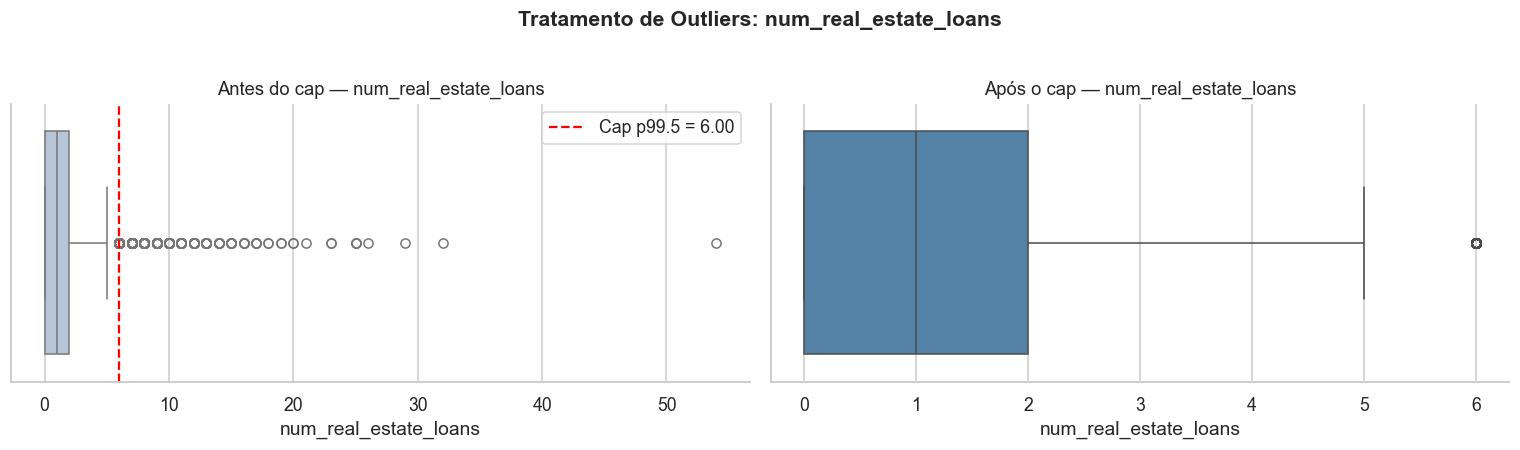

📌 num_real_estate_loans: cap aplicado em p99.5 = 6.0000  |  registros afetados: 793


In [31]:
cap_re = analyze_and_cap(df_renamed, 'num_real_estate_loans', percentile=0.995)

> **Decisão:** Cap no **percentil 99,5** — preserva valores plausíveis de múltiplos imóveis e remove apenas os extremos inconsistentes.

### 4.9 `num_dependents`

Número de dependentes declarados. Além do cap por percentil, garantimos que o campo seja do tipo inteiro — a imputação pela moda pode ter introduzido um float (ex: `0.0` em vez de `0`).

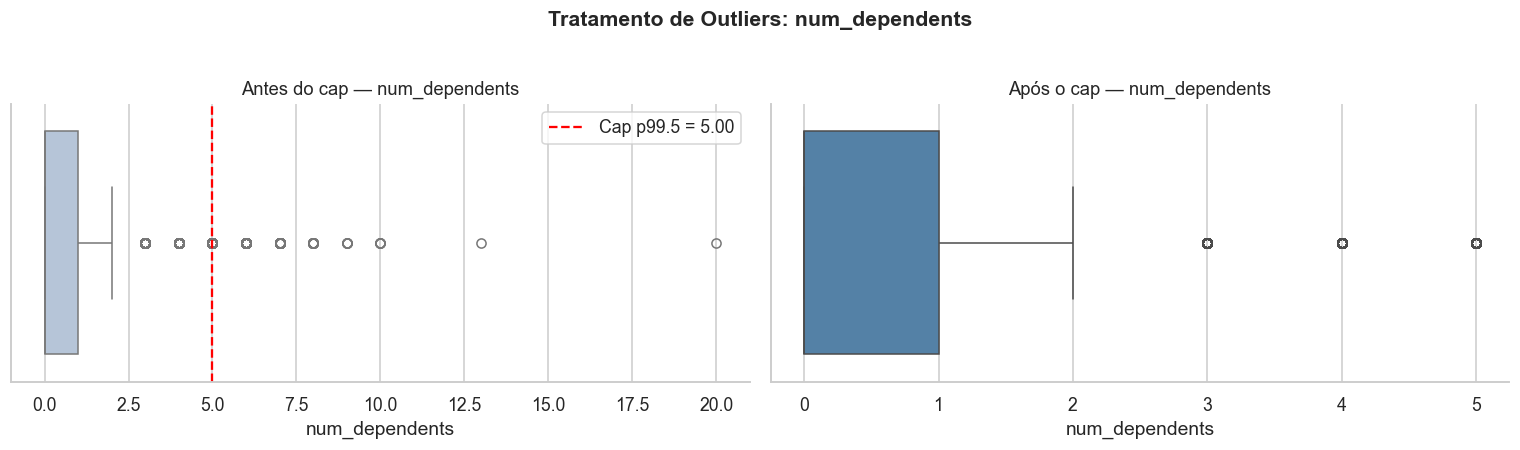

📌 num_dependents: cap aplicado em p99.5 = 5.0000  |  registros afetados: 991

Tipo após conversão: int64


In [32]:
# Garantir tipo inteiro (a imputação pode ter introduzido float)
df_renamed['num_dependents'] = df_renamed['num_dependents'].round().astype(int)

# Cap por percentil
cap_dep = analyze_and_cap(df_renamed, 'num_dependents', percentile=0.995)

print(f'\nTipo após conversão: {df_renamed["num_dependents"].dtype}')

> **Decisão:** Cap no **percentil 99,5** + conversão para `int` — valores muito altos de dependentes são improváveis; a conversão garante integridade do tipo.

---

## 5. Verificação Final do Dataset

Antes de exportar, validamos que o dataset está livre de valores ausentes, com tipos corretos e dentro dos domínios esperados.

In [33]:
print('=== Estrutura Final ===')
df_renamed.info()
print()

print('=== Valores Ausentes ===')
missing_final = (df_renamed.isna().mean() * 100).sort_values(ascending=False)
print(missing_final[missing_final > 0] if missing_final.any() else '✅ Nenhum valor ausente.')
print()

print('=== Dimensões Finais ===')
print(f'Linhas: {df_renamed.shape[0]:,}  |  Colunas: {df_renamed.shape[1]}')

=== Estrutura Final ===
<class 'pandas.DataFrame'>
Index: 149999 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   target_default_2y      149999 non-null  int64  
 1   revolving_utilization  149999 non-null  float64
 2   age                    149999 non-null  int64  
 3   debt_ratio             149999 non-null  float64
 4   monthly_income         149999 non-null  float64
 5   num_credit_lines       149999 non-null  int64  
 6   late_30_59_days        149999 non-null  int64  
 7   late_60_89_days        149999 non-null  int64  
 8   late_90_plus_days      149999 non-null  int64  
 9   num_real_estate_loans  149999 non-null  int64  
 10  num_dependents         149999 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 13.7 MB

=== Valores Ausentes ===
✅ Nenhum valor ausente.

=== Dimensões Finais ===
Linhas: 149,999  |  Colunas: 11


In [34]:
# Estatísticas descritivas — confirmação de que os caps foram aplicados corretamente
df_renamed.describe().T

,count,mean,std,min,25%,50%,75%,max
target_default_2y,149999.00,0.07,0.25,0.00,0.00,0.00,0.00,1.00
revolving_utilization,149999.00,0.32,0.35,0.00,0.03,0.15,0.56,1.00
age,149999.00,52.30,14.77,21.00,41.00,52.00,63.00,109.00
debt_ratio,149999.00,316.55,906.97,0.00,0.18,0.37,0.87,4979.08
monthly_income,149999.00,6142.45,3835.69,0.00,3903.00,5400.00,7400.00,23000.00
num_credit_lines,149999.00,8.43,5.03,0.00,5.00,8.00,11.00,27.00
late_30_59_days,149999.00,0.25,0.70,0.00,0.00,0.00,0.00,5.00
late_60_89_days,149999.00,0.07,0.33,0.00,0.00,0.00,0.00,3.00
late_90_plus_days,149999.00,0.09,0.45,0.00,0.00,0.00,0.00,4.00
num_real_estate_loans,149999.00,1.01,1.04,0.00,0.00,1.00,2.00,6.00


In [35]:
# Resumo dos caps aplicados
caps_summary = {
    'revolving_utilization' : ('Fixo', 1.0),
    'debt_ratio'            : ('p99',  df_renamed['debt_ratio'].max()),
    'monthly_income'        : ('p99',  df_renamed['monthly_income'].max()),
    'num_credit_lines'      : ('p99.5',df_renamed['num_credit_lines'].max()),
    'late_30_59_days'       : ('p99.5',df_renamed['late_30_59_days'].max()),
    'late_60_89_days'       : ('p99.5',df_renamed['late_60_89_days'].max()),
    'late_90_plus_days'     : ('p99.5',df_renamed['late_90_plus_days'].max()),
    'num_real_estate_loans' : ('p99.5',df_renamed['num_real_estate_loans'].max()),
    'num_dependents'        : ('p99.5',df_renamed['num_dependents'].max()),
}

summary_df = pd.DataFrame(caps_summary, index=['Critério', 'Valor Máximo Aplicado']).T
print('=== Resumo dos Caps Aplicados ===')
display(summary_df)

=== Resumo dos Caps Aplicados ===


,Critério,Valor Máximo Aplicado
revolving_utilization,Fixo,1.00
debt_ratio,p99,4979.08
monthly_income,p99,23000.00
num_credit_lines,p99.5,27
late_30_59_days,p99.5,5
late_60_89_days,p99.5,3
late_90_plus_days,p99.5,4
num_real_estate_loans,p99.5,6
num_dependents,p99.5,5


---

## 6. Exportação

O dataset limpo é salvo em formato **Parquet** — mais eficiente em armazenamento e leitura do que CSV, com preservação automática dos tipos de dados.

In [36]:
output_path = '../data/processed/cs-training_cleaned.parquet'
df_renamed.to_parquet(output_path, index=False)

print(f'✅ Dataset exportado com sucesso para: {output_path}')
print(f'   Linhas: {df_renamed.shape[0]:,}  |  Colunas: {df_renamed.shape[1]}')

✅ Dataset exportado com sucesso para: ../data/processed/cs-training_cleaned.parquet
   Linhas: 149,999  |  Colunas: 11


---

## 7. Sumário do Pipeline de Limpeza

| Etapa | Variável | Tratamento Aplicado | Critério |
|---|---|---|---|
| Remoção de coluna | `Unnamed: 0` | Drop | Sem valor analítico |
| Padronização | Todas | Rename para `snake_case` | Legibilidade e consistência |
| Imputação | `monthly_income` | Mediana | Distribuição não-normal com outliers |
| Imputação | `num_dependents` | Moda | Variável discreta concentrada |
| Remoção de registros | `age` | Drop se `age < 21` | Valor impossível (1 registro com idade 0) |
| Cap | `revolving_utilization` | Fixo em 1,0 | Limite semântico do campo |
| Cap | `debt_ratio` | Percentil 99 | Superendividamento válido; extremos inconsistentes |
| Cap | `monthly_income` | Percentil 99 | Outliers de renda extremos |
| Cap | `num_credit_lines` | Percentil 99,5 | Valores improváveis |
| Cap | `late_30_59_days` | Percentil 99,5 | Janela temporal de 2 anos |
| Cap | `late_60_89_days` | Percentil 99,5 | Janela temporal de 2 anos |
| Cap | `late_90_plus_days` | Percentil 99,5 | Janela temporal de 2 anos |
| Cap | `num_real_estate_loans` | Percentil 99,5 | Valores improváveis |
| Cap + Tipo | `num_dependents` | Percentil 99,5 + `int` | Contagem inteira; extremos improváveis |

---
> 📁 Próximo notebook: `02_analise_exploratoria.ipynb`